In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchsummary import summary

In [3]:
raw = imread('../../Data/pneumoniamnist_224.npz')

/var/folders/tf/j4q2snk50tqd8r7zkdzp3q1h0000gn/T/ipykernel_96142/2823394576.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(raw[0])


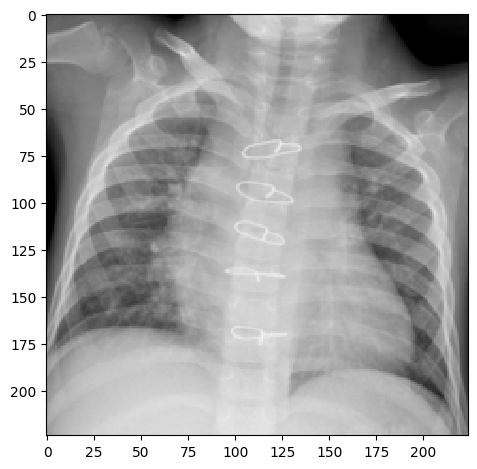

In [4]:
imshow(raw[0])

In [5]:
class Pneumonia(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

0 (224, 224)
1 (224, 224)
2 (224, 224)
3 (224, 224)


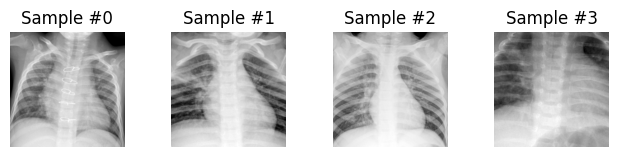

In [6]:
pneumonia = Pneumonia(raw)

fig = plt.figure()

for i in range(len(pneumonia)):
    sample = pneumonia[i]

    print(i, sample.shape)

    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    plt.imshow(sample, cmap='gray')

    if i == 3:
        plt.show()
        break

In [7]:
tran_pneumonia = Pneumonia(raw, transform=torch.from_numpy(raw).float())

In [8]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3),
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(16, 8, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 5, stride=3, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 4, stride=2)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [9]:
model = AE()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
summary(model, (1, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 74, 74]             160
              ReLU-2           [-1, 16, 74, 74]               0
         MaxPool2d-3           [-1, 16, 37, 37]               0
            Conv2d-4            [-1, 8, 19, 19]           1,160
              ReLU-5            [-1, 8, 19, 19]               0
         MaxPool2d-6            [-1, 8, 18, 18]               0
   ConvTranspose2d-7           [-1, 16, 37, 37]           1,168
              ReLU-8           [-1, 16, 37, 37]               0
   ConvTranspose2d-9          [-1, 8, 111, 111]           3,208
             ReLU-10          [-1, 8, 111, 111]               0
  ConvTranspose2d-11          [-1, 1, 224, 224]             129
Total params: 5,825
Trainable params: 5,825
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.19
Forward/back

In [11]:
pn_loader = DataLoader(tran_pneumonia, batch_size=64, shuffle=True)

In [32]:
epochs = 100
outputs = []
losses = []

for epoch in range(epochs):
    for (i, data) in enumerate(pn_loader):
        img = data.float().unsqueeze(1)
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss)
        if i % 10 == 0:
            print(f'Epoch:{epoch+1}, Batch:{i}, Loss:{loss.item()}')
    if epoch % 10 == 0:
        outputs.append((epoch, img, recon))
    print(f'Epoch:{epoch+1}, Loss:{loss.item()}')

Epoch:1, Batch:0, Loss:136.64930725097656
Epoch:1, Batch:10, Loss:129.0516357421875
Epoch:1, Batch:20, Loss:129.5800018310547
Epoch:1, Batch:30, Loss:131.42715454101562
Epoch:1, Batch:40, Loss:141.38694763183594
Epoch:1, Batch:50, Loss:141.89157104492188
Epoch:1, Batch:60, Loss:125.77093505859375
Epoch:1, Batch:70, Loss:127.26478576660156
Epoch:1, Loss:126.04810333251953
Epoch:2, Batch:0, Loss:127.16497802734375
Epoch:2, Batch:10, Loss:143.30323791503906
Epoch:2, Batch:20, Loss:122.62506103515625
Epoch:2, Batch:30, Loss:135.93978881835938
Epoch:2, Batch:40, Loss:133.0161590576172
Epoch:2, Batch:50, Loss:127.68248748779297
Epoch:2, Batch:60, Loss:148.72189331054688
Epoch:2, Batch:70, Loss:128.51197814941406
Epoch:2, Loss:133.15704345703125
Epoch:3, Batch:0, Loss:122.51826477050781
Epoch:3, Batch:10, Loss:136.24131774902344
Epoch:3, Batch:20, Loss:120.94170379638672
Epoch:3, Batch:30, Loss:126.4620132446289
Epoch:3, Batch:40, Loss:115.90726470947266
Epoch:3, Batch:50, Loss:126.0981826782

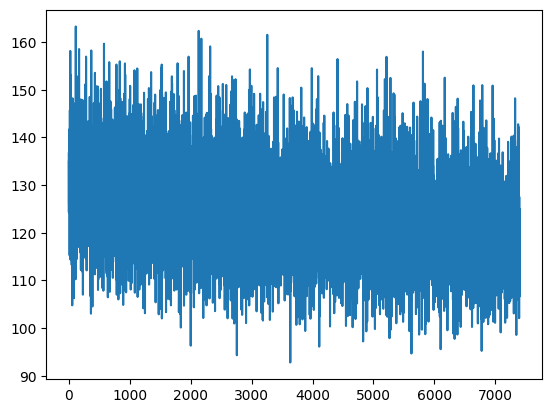

In [33]:
losses = np.array([losses[i].detach().numpy() for i in range(len(losses))])

plt.plot(losses)

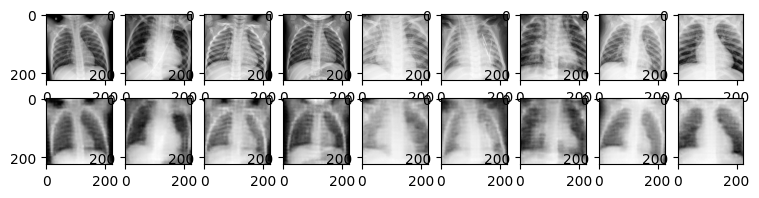

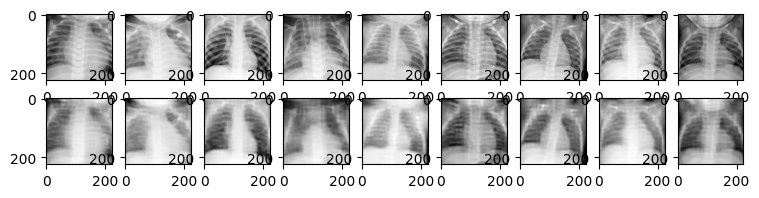

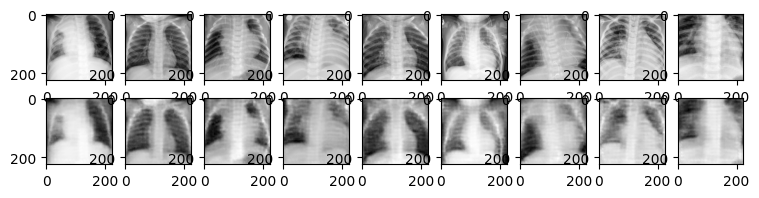

In [34]:
for k in range(0, epochs // 10, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9:
            break
        plt.subplot(2, 9, i + 1)
        plt.imshow(item[0])
    for i, item in enumerate(recon):
        if i >= 9:
            break
        plt.subplot(2, 9, 9 + i + 1)
        plt.imshow(item[0])

/var/folders/tf/j4q2snk50tqd8r7zkdzp3q1h0000gn/T/ipykernel_96142/2471826610.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(outputs[-1][1].detach().numpy()[0][0], cmap='gray')
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


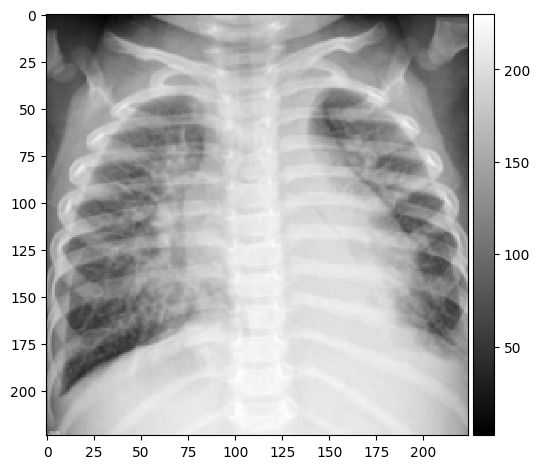

In [35]:
imshow(outputs[-1][1].detach().numpy()[0][0], cmap='gray')

/var/folders/tf/j4q2snk50tqd8r7zkdzp3q1h0000gn/T/ipykernel_96142/1515799138.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(outputs[-1][2].detach().numpy()[0][0], cmap='gray')
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


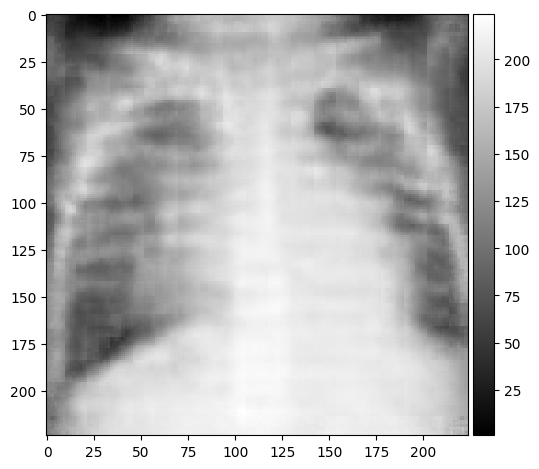

In [36]:
imshow(outputs[-1][2].detach().numpy()[0][0], cmap='gray')